## 7. Matrislerle Adım Adım 1 İterasyon (Manuel Hesaplama)
 
Python'un `dot()` fonksiyonunun arka planda ne yaptığını anlamak için sadece 2 örnekten ($m=2$) oluşan minik bir veri seti hayal edilir:
 
* 1. Örnek: $x=2$, Gerçek değer $y=5$
* 2. Örnek: $x=3$, Gerçek değer $y=7$
Öğrenme oranı ($\eta$) = 0.1 olur ve model tahmin yapmaya rastgele **$\theta_0 = 1$ (Kesişim/Bias)** ve **$\theta_1 = 1$ (Eğim/Ağırlık)** ile başlar.
 
### 1. Başlangıç Matrislerini Kurma
 
Özelliklere ($x$) bias için bir sütun $1$ ekleyerek $\mathbf{X}_b$ matrisini oluşturulur. Hedef değerler $\mathbf{y}$ ve parametreler $\boldsymbol{\theta}$ da birer vektördür.
 
$$ \mathbf{X}_b = \begin{bmatrix} 1 & 2 \\ 1 & 3 \end{bmatrix}, \quad \mathbf{y} = \begin{bmatrix} 5 \\ 7 \end{bmatrix}, \quad \boldsymbol{\theta} = \begin{bmatrix} 1 \\ 1 \end{bmatrix} $$
 
### 2. Tahmin Yapma (Hypothesis) $\rightarrow \mathbf{X}_b \cdot \boldsymbol{\theta}$
 
Modelin ilk tahmini, veri matrisi ile ağırlık vektörünün çarpılmasıdır (Satır $\times$ Sütun):
 
$$ \mathbf{\hat{y}} = \begin{bmatrix} 1 & 2 \\ 1 & 3 \end{bmatrix} \begin{bmatrix} 1 \\ 1 \end{bmatrix} = \begin{bmatrix} (1 \cdot 1) + (2 \cdot 1) \\ (1 \cdot 1) + (3 \cdot 1) \end{bmatrix} = \begin{bmatrix} 3 \\ 4 \end{bmatrix} $$
 
*(Yani ilk tahminde model 5 yerine 3, 7 yerine 4 sonucunu buldu).*
 
### 3. Hata Hesaplama (Error) $\rightarrow \mathbf{\hat{y}} - \mathbf{y}$
 
Tahminlerimizden gerçek $\mathbf{y}$ değerlerini çıkararak hatamızı (farkı) matris olarak buluruz:
 
$$ \text{Hata} = \begin{bmatrix} 3 \\ 4 \end{bmatrix} - \begin{bmatrix} 5 \\ 7 \end{bmatrix} = \begin{bmatrix} -2 \\ -3 \end{bmatrix} $$
 
### 4. Gradyanları (Kısmi Türevleri) Bulma $\rightarrow \frac{2}{m} \mathbf{X}_b^T \cdot \text{Hata}$
 
Hangi parametrenin ne kadar değiştirileceğin bulmak için $\mathbf{X}_b$ matrisinin **transpozunu (devriğini)** alıp hata vektörü ile çarpılır. ($m=2$ olduğu için baştaki $2/m$ çarpanı $1$ olur).
 
$$ \mathbf{X}_b^T = \begin{bmatrix} 1 & 1 \\ 2 & 3 \end{bmatrix} $$
 
$$ \text{Gradyan} = 1 \cdot \begin{bmatrix} 1 & 1 \\ 2 & 3 \end{bmatrix} \begin{bmatrix} -2 \\ -3 \end{bmatrix} = \begin{bmatrix} (1 \cdot -2) + (1 \cdot -3) \\ (2 \cdot -2) + (3 \cdot -3) \end{bmatrix} = \begin{bmatrix} -5 \\ -13 \end{bmatrix} $$
 
*Gradyanların negatif çıkması, hatayı azaltmak için $\theta$ değerlerini BÜYÜTÜLMESİ gerektiğini söylüyor. (dar açı pozitif, geniş açı negatif. -- tanjanttan dolayı)*
 
### 5. Parametreleri Güncelleme $\rightarrow \boldsymbol{\theta}_{\text{yeni}} = \boldsymbol{\theta} - \eta \cdot \text{Gradyan}$
 
Eski $\boldsymbol{\theta}$ değerlerimizden, gradyanın öğrenme oranı (0.1) ile küçültülmüş halini çıkararak yeni ve daha zeki $\boldsymbol{\theta}$ değerlerimizi buluyoruz:
 
$$ \boldsymbol{\theta}_{\text{yeni}} = \begin{bmatrix} 1 \\ 1 \end{bmatrix} - 0.1 \begin{bmatrix} -5 \\ -13 \end{bmatrix} $$
 
$$ \boldsymbol{\theta}_{\text{yeni}} = \begin{bmatrix} 1 \\ 1 \end{bmatrix} - \begin{bmatrix} -0.5 \\ -1.3 \end{bmatrix} = \begin{bmatrix} 1.5 \\ 2.3 \end{bmatrix} $$
 
**Sonuç:** Sadece tek bir matris iterasyonu ile modelin parametreleri $1$ ve $1$'den; $\mathbf{b = 1.5}$ ve $\mathbf{a = 2.3}$'e yükseldi! İkinci iterasyonda bu yeni değerler üzerinden işlemler tekrarlanacak ve doğru çizgi, veri noktalarına her adımda biraz daha yaklaşacak.
 
### 6. Kavramların Özeti
 
- $\boldsymbol{\theta}_{\text{eski}}$: Modelin o anki "cahil" durumu. (Başlangıçta $[1, 1]$).
- **Gradyan**: Hatanın azaltılması için parametrelerin hangi yönde ve ne kadar değişmesi gerektiğini söyleyen pusula. (Negatif olması, değerlerin büyümesi gerektiğini gösterir).
- $\boldsymbol{\theta}_{\text{yeni}}$: Gradyan pusulasına bakılarak atılan adımdan sonraki "daha zeki" durum. (Güncellenmiş değerler: $[1.5, 2.3]$).
- **Transpoz ($\mathbf{X}_b^T$)**: Her bir parametrenin (Bias veya Ağırlık) kendi özelliğine ($\mathbf{X}$ sütunu) sadık kalarak, hatayı kendi faturasıyla çarpmasını sağlayan ve parametrelerin birbirine karışmasını engelleyen matris düzeltme işlemidir.
---


In [1]:
%pip install plotly ipywidgets
%pip install nbformat
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from ipywidgets import interact

# Çubuklardaki yazılar (description) kesilmesin diye özel stil ayarı
stil = {'description_width': 'initial'}
duzen = widgets.Layout(width='600px') # Çubuğun ekrandaki uzunluğu

def plotly_3d_gradyan_inisi(baslangic_theta0, baslangic_theta1, ogrenme_orani, iterasyon_sayisi):
    
    # 1. 3 Boyutlu Kaseyi Oluştur: J(θ0, θ1) = θ0² + θ1²
    th0_grid = np.linspace(-5, 5, 50)
    th1_grid = np.linspace(-5, 5, 50)
    TH0, TH1 = np.meshgrid(th0_grid, th1_grid)
    MALIYET = TH0**2 + TH1**2
    
    # 2. Seçilen ayarlarla Gradyan İnişini hesapla
    theta0 = baslangic_theta0
    theta1 = baslangic_theta1
    
    theta0_gecmisi = [theta0]
    theta1_gecmisi = [theta1]
    maliyet_gecmisi = [theta0**2 + theta1**2]
    
    for _ in range(iterasyon_sayisi):
        gradyan0 = 2 * theta0
        gradyan1 = 2 * theta1
        
        theta0 = theta0 - (ogrenme_orani * gradyan0)
        theta1 = theta1 - (ogrenme_orani * gradyan1)
        
        theta0_gecmisi.append(theta0)
        theta1_gecmisi.append(theta1)
        maliyet_gecmisi.append(theta0**2 + theta1**2)
        
    # 3. PLOTLY İLE İNTERAKTİF ÇİZİM
    fig = go.Figure()
    
    # Yüzeyi (Kaseyi) Ekle
    fig.add_trace(go.Surface(
        z=MALIYET, x=th0_grid, y=th1_grid, 
        colorscale='Viridis', opacity=0.7, 
        name='Maliyet Yüzeyi',
        showscale=False # Yandaki renk çubuğunu gizle (kalabalık yapmasın)
    ))
    
    # Adımları (Kırmızı topun yolu) Ekle
    fig.add_trace(go.Scatter3d(
        x=theta0_gecmisi, y=theta1_gecmisi, z=maliyet_gecmisi,
        mode='lines+markers',
        marker=dict(size=6, color='red'),
        line=dict(color='red', width=5),
        name='Öğrenme Yolu'
    ))
    
    # Başlangıç ve Bitiş noktalarını büyük toplarla göster
    fig.add_trace(go.Scatter3d(
        x=[theta0_gecmisi[0]], y=[theta1_gecmisi[0]], z=[maliyet_gecmisi[0]],
        mode='markers', marker=dict(size=10, color='orange'), name='Başlangıç'
    ))
    fig.add_trace(go.Scatter3d(
        x=[theta0_gecmisi[-1]], y=[theta1_gecmisi[-1]], z=[maliyet_gecmisi[-1]],
        mode='markers', marker=dict(size=10, color='green'), name='Son Durum'
    ))
    
    # Grafiğin genel tasarımı (Kamera, başlıklar vb.)
    fig.update_layout(
        title=f"Plotly 3D Gradyan İnişi | Ulaşılan Hata: {maliyet_gecmisi[-1]:.4f}",
        width=800, height=600,
        margin=dict(l=0, r=0, b=0, t=40), # Kenar boşluklarını sıfırla
        scene=dict(
            xaxis_title='θ0 Değeri',
            yaxis_title='θ1 Değeri',
            zaxis_title='Hata (Maliyet)'
        )
    )
    
    fig.show()

# 4. İnteraktif Çubukları Oluşturma (Genişletilmiş Yazılarla)
interact(
    plotly_3d_gradyan_inisi,
    baslangic_theta0=widgets.FloatSlider(value=-4.0, min=-5.0, max=5.0, step=0.5, description='Başlangıç (θ0 Ekseni):', style=stil, layout=duzen),
    baslangic_theta1=widgets.FloatSlider(value=4.0, min=-5.0, max=5.0, step=0.5, description='Başlangıç (θ1 Ekseni):', style=stil, layout=duzen),
    ogrenme_orani=widgets.FloatSlider(value=0.10, min=0.01, max=1.10, step=0.01, description='Öğrenme Oranı (η):', style=stil, layout=duzen),
    iterasyon_sayisi=widgets.IntSlider(value=15, min=1, max=50, step=1, description='Toplam İterasyon (Adım):', style=stil, layout=duzen)
);

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


interactive(children=(FloatSlider(value=-4.0, description='Başlangıç (θ0 Ekseni):', layout=Layout(width='600px…

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
#veriyi olusturma
m = 100 # veri sayisi
X = np.random.rand(m, 1)
y = 3 + 4 * X + np.random.rand(m, 1)
# Matris carpimi icin X dizisine 1'lerden olusan yeni bir sutun ekle - bias icin
# np.c_ komutu iki diziyi yan yana birlestirir
X_b = np.c_[np.ones((m,1)), X]

print("X_b'nin ilk 3 satiri:\n", X_b[:3])

X_b'nin ilk 3 satiri:
 [[1.         0.83746529]
 [1.         0.61521212]
 [1.         0.47386775]]


In [9]:
# ogrenme orani ve iterasyon
eta = 0.1
n_iterations = 1000

# parametreleri (theta: hem b hem de a'yi icerir) rastgele baslat
# theta matrisi: [b, a] seklinde 2x1 boyutunda bir vektor
theta = np.random.randn(2,1)

for iteration in range(n_iterations):
    # matris carpimi: tahminleri ve hatayi bul
    # gradients = (2/m) * X.T * (Tahmin - Gercek Y)
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)

    # parametre vektorunu guncelle
    theta = theta - eta * gradients

print("Ogrenilen kesisim(b): ",theta[0][0])
print("Ogrenilmis Egim(a): ", theta[1][0])

Ogrenilen kesisim(b):  3.481166753670932
Ogrenilmis Egim(a):  4.032066450616809


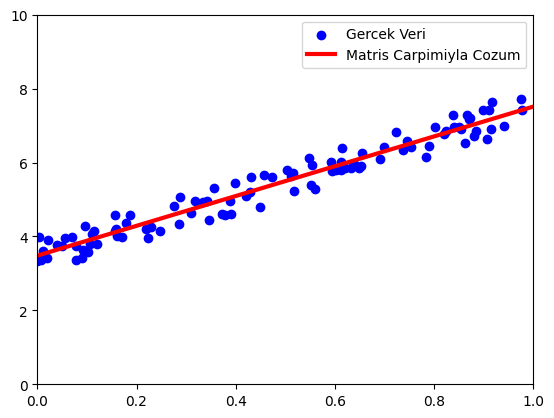

In [11]:
# gorsellestirme
X_new = np.array([[0], [1]])
X_new_b = np.c_[np.ones((2,1)), X_new]      # yeni veriye de bias ekle
y_predict = X_new_b.dot(theta)

plt.scatter(X, y, color="blue", label='Gercek Veri')
plt.plot(X_new, y_predict, "r-", linewidth=3, label='Matris Carpimiyla Cozum')
plt.axis([0, 1, 0, 10])
plt.legend()
plt.show()